# Gabarito — Pontos Notáveis do Triângulo

Este notebook traz a resolução comentada dos exercícios de [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb).

⚠️ **Antes de olhar aqui:** tente resolver os exercícios sozinho no notebook original e use as células de verificação (`assert`) para conferir sua resposta. Volte a este gabarito só depois de tentar — ou se travar de verdade em algum passo.

In [1]:
# Imports necessários para os exercícios abaixo
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import patheffects
from matplotlib.patches import Circle, Polygon

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


# Ferramentas do notebook principal (reconstruídas aqui).
def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Deixa o eixo pronto para desenhos de geometria (estilo Nord, sem grade, sem números,
    escala igual) e enquadra todos os `pontos` com uma margem em volta."""
    estilizar_eixo(ax)
    ax.grid(False)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def direcao(angulo_graus: float) -> np.ndarray:
    """Vetor de tamanho 1 apontando na direção dada, em graus, a partir da horizontal (sentido anti-horário).

    (cos e sin vêm da Trigonometria, módulo 05; aqui só servem para apontar na direção certa.)
    """
    rad = math.radians(angulo_graus)
    return np.array([math.cos(rad), math.sin(rad)])


def direcao_de(origem, destino) -> float:
    """Direção, em graus, em que `destino` está quando visto de `origem`."""
    return math.degrees(math.atan2(destino[1] - origem[1], destino[0] - origem[0]))


def medir_angulo(vertice, P, Q) -> float:
    """Transferidor digital: medida, em graus, do ângulo com vértice em `vertice`
    formado pelas semirretas que passam por P e por Q (resultado entre 0° e 180°)."""
    u = np.subtract(P, vertice)
    v = np.subtract(Q, vertice)
    cosseno = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return math.degrees(math.acos(np.clip(cosseno, -1, 1)))


def cruzamento(P, inclinacao_1: float, Q, inclinacao_2: float):
    """Ponto em que a reta que passa por P (com a inclinação `inclinacao_1`, em graus) cruza a reta
    que passa por Q (com a inclinação `inclinacao_2`). Devolve None se as duas retas tiverem a mesma
    direção, porque aí elas não se cruzam num ponto só.

    Por trás, é um sistema linear 2×2 (módulo 03): P + t·u = Q + k·v, com incógnitas t e k.
    """
    matriz = np.column_stack([direcao(inclinacao_1), -direcao(inclinacao_2)])
    if abs(np.linalg.det(matriz)) < 1e-12:
        return None
    t, _ = np.linalg.solve(matriz, np.subtract(Q, P))
    return np.array(P, dtype=float) + t * direcao(inclinacao_1)


def ponto_medio(P, Q) -> np.ndarray:
    """Ponto médio do segmento PQ: a média das coordenadas (0402a)."""
    return (np.asarray(P, dtype=float) + np.asarray(Q, dtype=float)) / 2


def orientacao(O, P, Q) -> float:
    """Multiplicação cruzada com sinal (0408a): zero se O, P e Q são colineares, positiva se o
    caminho O → P → Q vira para a esquerda e negativa se vira para a direita."""
    return (P[0] - O[0]) * (Q[1] - O[1]) - (P[1] - O[1]) * (Q[0] - O[0])


def inclinacao_da_perpendicular(inclinacao_r: float) -> float:
    """Inclinação da perpendicular a uma reta de inclinação `inclinacao_r`: girar 90° (a menos de 180°)."""
    return (inclinacao_r + 90) % 180


def projecao_ortogonal(P, ponto_r, inclinacao_r: float) -> np.ndarray:
    """Projeção ortogonal P' de P sobre a reta r (que passa por `ponto_r`, com a inclinação dada):
    o pé da perpendicular a r traçada por P (0407a)."""
    return cruzamento(P, inclinacao_da_perpendicular(inclinacao_r), ponto_r, inclinacao_r)


def distancia_ponto_reta(P, ponto_r, inclinacao_r: float) -> float:
    """Distância de P à reta r: a medida de PP', com P' a projeção ortogonal de P sobre r (0407a)."""
    return math.dist(P, projecao_ortogonal(P, ponto_r, inclinacao_r))


# Uma cor fixa para cada ponto notável e para a família de linhas que o gera (vale no notebook inteiro)
CORES_NOTAVEIS = {"G": COR_PONTO, "I": COR_DESTAQUE, "O": COR_AVISO, "H": COR_EXTRA}
NOMES_NOTAVEIS = {"G": "baricentro", "I": "incentro", "O": "circuncentro", "H": "ortocentro"}
LINHAS_NOTAVEIS = {"G": "medianas", "I": "bissetrizes internas", "O": "mediatrizes", "H": "alturas"}
COR_TRIANGULO = NORD_TEXTO_SEC
COR_EULER = COR_ALERTA


def como_pontos(*pontos) -> list[np.ndarray]:
    """Converte pares (x, y) em arrays do numpy, para fazer contas com as coordenadas."""
    return [np.asarray(p, dtype=float) for p in pontos]


def iguais(x: float, y: float) -> bool:
    """Compara duas medidas com uma tolerância pequena (as contas com float têm arredondamentos)."""
    return math.isclose(x, y, rel_tol=1e-9, abs_tol=1e-6)


def eh_triangulo(A, B, C) -> bool:
    """True se A, B e C não são colineares (multiplicação cruzada diferente de zero, 0401a)."""
    return abs(orientacao(A, B, C)) > 1e-9


def lados_do_triangulo(A, B, C) -> tuple[float, float, float]:
    """Medidas a = BC, b = CA e c = AB (cada letra minúscula é o lado oposto ao vértice de mesma letra, 0404a)."""
    return math.dist(B, C), math.dist(C, A), math.dist(A, B)


def angulos_do_triangulo(A, B, C) -> tuple[float, float, float]:
    """Medidas, em graus, dos ângulos internos Â, B̂ e Ĉ (com o transferidor digital)."""
    return medir_angulo(A, B, C), medir_angulo(B, C, A), medir_angulo(C, A, B)


def classificar_por_angulos(A, B, C) -> str:
    """'acutângulo', 'retângulo' ou 'obtusângulo', olhando para o maior ângulo (0404a)."""
    maior = max(angulos_do_triangulo(A, B, C))
    if math.isclose(maior, 90, abs_tol=1e-6):
        return "retângulo"
    return "obtusângulo" if maior > 90 else "acutângulo"


def posicao_no_triangulo(P, A, B, C) -> str:
    """Onde o ponto P está em relação ao triângulo ABC: 'dentro', 'sobre um vértice', 'sobre um lado'
    ou 'fora'. Usa o sinal da multiplicação cruzada (0408a): P está dentro quando fica, em relação a
    cada lado, do mesmo lado que o vértice oposto."""
    if any(math.dist(P, V) < 1e-6 for V in (A, B, C)):
        return "sobre um vértice"
    sentido = 1 if orientacao(A, B, C) > 0 else -1
    # distância com sinal de P a cada lado: positiva do lado de dentro, negativa do lado de fora
    distancias = [sentido * orientacao(X, Y, P) / math.dist(X, Y) for X, Y in ((A, B), (B, C), (C, A))]
    if any(d < -1e-6 for d in distancias):
        return "fora"
    if any(abs(d) <= 1e-6 for d in distancias):
        return "sobre um lado"
    return "dentro"


def distancias_aos_lados(P, A, B, C) -> tuple[float, float, float]:
    """Distâncias de P às retas BC, CA e AB, nessa ordem (distância de ponto a reta, 0407a)."""
    return tuple(distancia_ponto_reta(P, X, direcao_de(X, Y)) for X, Y in ((B, C), (C, A), (A, B)))


def esta_no_segmento(X, P, Q) -> bool:
    """True se o ponto X, que já sabemos estar na reta PQ, fica entre P e Q (inclusive nas pontas)."""
    X, P, Q = (np.asarray(p, dtype=float) for p in (X, P, Q))
    t = np.dot(X - P, Q - P) / np.dot(Q - P, Q - P)
    return -1e-9 <= t <= 1 + 1e-9


def desenhar_triangulo(ax, A, B, C, cor: str = COR_TRIANGULO, largura: float = 2.5, preencher: bool = True,
                       nomes: str = "ABC", distancia: float = 0.4) -> None:
    """Desenha o triângulo ABC (lados e interior levemente pintado) e escreve os nomes dos vértices
    do lado de fora da figura."""
    if preencher:
        ax.add_patch(Polygon([A, B, C], closed=True, facecolor=COR_SECUNDARIA, alpha=0.12, edgecolor="none"))
    for P, Q in ((A, B), (B, C), (C, A)):
        ax.plot(*zip(P, Q), color=cor, lw=largura, solid_capstyle="round", zorder=3)
    centro = (np.asarray(A) + np.asarray(B) + np.asarray(C)) / 3
    for V, nome in zip((A, B, C), nomes):
        V = np.asarray(V, dtype=float)
        ax.plot(*V, "o", color=NORD_TEXTO, markersize=6, zorder=6)
        afastar = V - centro
        afastar = afastar / np.linalg.norm(afastar) if np.linalg.norm(afastar) > 0 else np.array([0.0, 1.0])
        ax.text(*(V + distancia * afastar), nome, color=NORD_TEXTO, fontsize=13, fontweight="bold",
                ha="center", va="center", zorder=7)


def rotular_fora(ax, P, texto: str, centro, cor: str = NORD_TEXTO, distancia: float = 0.35,
                 tamanho: int = 12) -> None:
    """Escreve `texto` perto do ponto P, afastado do `centro` (para não ficar em cima da figura)."""
    P = np.asarray(P, dtype=float)
    afastar = P - np.asarray(centro, dtype=float)
    afastar = afastar / np.linalg.norm(afastar) if np.linalg.norm(afastar) > 0 else np.array([0.0, 1.0])
    ax.text(*(P + distancia * afastar), texto, color=cor, fontsize=tamanho, fontweight="bold",
            ha="center", va="center", zorder=7)


def desenhar_reta(ax, P, Q, cor: str, estilo: str = "--", largura: float = 1.5, alpha: float = 0.9) -> None:
    """Desenha a reta inteira que passa por P e por Q (até a borda do gráfico)."""
    ax.axline(tuple(np.asarray(P, dtype=float)), tuple(np.asarray(Q, dtype=float)), color=cor,
              linestyle=estilo, lw=largura, alpha=alpha, zorder=2)


def desenhar_circunferencia(ax, centro, raio: float, cor: str, estilo: str = "-", largura: float = 2.0) -> None:
    """Desenha a circunferência de centro e raio dados (só a linha, sem pintar o interior)."""
    ax.add_patch(Circle(tuple(np.asarray(centro, dtype=float)), raio, fill=False, edgecolor=cor, lw=largura,
                        linestyle=estilo, zorder=3))


DESLOCAMENTO_NOTAVEL = {"G": (0.15, 0.15), "I": (-0.5, 0.15), "O": (0.15, -0.55), "H": (-0.5, -0.55)}


def marcar_notavel(ax, P, letra: str, deslocamento=None, tamanho: int = 11) -> None:
    """Marca um ponto notável com a cor da sua família (G, I, O ou H) e escreve a letra ao lado."""
    cor = CORES_NOTAVEIS[letra]
    dx, dy = DESLOCAMENTO_NOTAVEL[letra] if deslocamento is None else deslocamento
    ax.plot(*P, "o", color=cor, markersize=tamanho, markeredgecolor=NORD_FUNDO, markeredgewidth=1.5, zorder=8)
    ax.text(P[0] + dx, P[1] + dy, letra, color=cor, fontsize=14, fontweight="bold", zorder=9,
            path_effects=[patheffects.withStroke(linewidth=3, foreground=NORD_FUNDO)])


# Os quatro pontos notáveis, como foram construídos nas seções 1 a 4.
def baricentro(A, B, C) -> np.ndarray:
    """Baricentro G do triângulo ABC: a média das coordenadas dos três vértices."""
    return (np.asarray(A, dtype=float) + np.asarray(B, dtype=float) + np.asarray(C, dtype=float)) / 3


def direcao_da_bissetriz(vertice, P, Q) -> float:
    """Inclinação, em graus, da bissetriz do ângulo de vértice `vertice` formado pelas semirretas que
    passam por P e por Q. É o truque do losango (0409a): somando os vetores de tamanho 1 que apontam
    para P e para Q, obtemos a diagonal de um losango, e a diagonal do losango é bissetriz."""
    V = np.asarray(vertice, dtype=float)
    u = (np.asarray(P, dtype=float) - V) / math.dist(V, P)
    w = (np.asarray(Q, dtype=float) - V) / math.dist(V, Q)
    return direcao_de(V, V + u + w)


def incentro(A, B, C) -> np.ndarray:
    """Incentro I do triângulo ABC: o cruzamento das bissetrizes internas de Â e de B̂."""
    return cruzamento(A, direcao_da_bissetriz(A, B, C), B, direcao_da_bissetriz(B, C, A))



def incentro_pela_formula(A, B, C) -> np.ndarray:
    """Atalho para o incentro: a média das coordenadas dos vértices ponderada pelos lados opostos,
    I = (a·A + b·B + c·C) / (a + b + c)."""
    a, b, c = lados_do_triangulo(A, B, C)
    A, B, C = como_pontos(A, B, C)
    return (a * A + b * B + c * C) / (a + b + c)


def circuncentro(A, B, C) -> np.ndarray:
    """Circuncentro O do triângulo ABC: o cruzamento das mediatrizes de AB e de BC
    (cada mediatriz é a perpendicular ao lado pelo seu ponto médio, 0407a)."""
    return cruzamento(ponto_medio(A, B), inclinacao_da_perpendicular(direcao_de(A, B)),
                      ponto_medio(B, C), inclinacao_da_perpendicular(direcao_de(B, C)))


def pe_da_altura(vertice, P, Q) -> np.ndarray:
    """Pé da altura traçada de `vertice` até a reta PQ: a projeção ortogonal do vértice sobre essa reta (0407a)."""
    return projecao_ortogonal(vertice, P, direcao_de(P, Q))


def ortocentro(A, B, C) -> np.ndarray:
    """Ortocentro H do triângulo ABC: o cruzamento das retas-suporte das alturas relativas a BC e a CA
    (cada uma é a perpendicular ao lado traçada pelo vértice oposto)."""
    return cruzamento(A, inclinacao_da_perpendicular(direcao_de(B, C)),
                      B, inclinacao_da_perpendicular(direcao_de(C, A)))


def pontos_notaveis(A, B, C) -> dict[str, np.ndarray]:
    """Os quatro pontos notáveis do triângulo ABC, no dicionário {"G": ..., "I": ..., "O": ..., "H": ...}."""
    return {"G": baricentro(A, B, C), "I": incentro(A, B, C), "O": circuncentro(A, B, C), "H": ortocentro(A, B, C)}

## Básico

**Exercício 1.** O baricentro do triângulo $A = (2, 7)$, $B = (-1, 1)$, $C = (8, 1)$ e a razão 2 : 1 na mediana $\overline{AM_a}$; os trechos de uma mediana de 12 cm.

In [2]:
A_ex1, B_ex1, C_ex1 = como_pontos((2, 7), (-1, 1), (8, 1))

# (a) O ponto médio é a média das coordenadas das extremidades (0402a).
M_a_ex1 = ponto_medio(B_ex1, C_ex1)  # ((−1 + 8) / 2, (1 + 1) / 2) = (3,5; 1)

# (b) O baricentro é a média das coordenadas dos TRÊS vértices.
G_ex1 = (A_ex1 + B_ex1 + C_ex1) / 3  # ((2 − 1 + 8) / 3, (7 + 1 + 1) / 3) = (3, 3)

# (c) A razão entre as duas partes da mediana.
AG, GM = math.dist(A_ex1, G_ex1), math.dist(G_ex1, M_a_ex1)
razao_ex1 = AG / GM

# (d) O baricentro divide a mediana em 3 partes iguais: 2 do lado do vértice e 1 do lado do ponto médio.
trecho_vertice_ex1 = 12 * 2 / 3
trecho_lado_ex1 = 12 * 1 / 3

print(f"M_a = {M_a_ex1},  G = {G_ex1}")
print(f"AG = {AG:.4f},  GM_a = {GM:.4f},  AG / GM_a = {razao_ex1:.4f}")
print(f"mediana de 12 cm: {trecho_vertice_ex1:g} cm (vértice → G) + {trecho_lado_ex1:g} cm (G → ponto médio)")
# AG = √(1² + 4²) = √17 e GM_a = √(0,5² + 2²) = √4,25 = √17 / 2: a razão dá exatamente 2.
# Atalho para conferir: AG = (2/3)·AM_a, e AM_a = √(1,5² + 6²) = √38,25 ≈ 6,185; 2/3 disso ≈ 4,123 = √17.

M_a = [3.5 1. ],  G = [3. 3.]
AG = 4.1231,  GM_a = 2.0616,  AG / GM_a = 2.0000
mediana de 12 cm: 8 cm (vértice → G) + 4 cm (G → ponto médio)


**Exercício 2.** Onde ficam o circuncentro e o ortocentro em cada tipo de triângulo, e quais pontos ficam sempre dentro.

In [3]:
# (a) Circuncentro: no retângulo, fica no ponto médio da hipotenusa (sobre um lado).
#     Ortocentro: no retângulo, fica no vértice do ângulo reto (sobre o triângulo também).
posicao_O_ex2 = {"acutângulo": "dentro", "retângulo": "sobre o triângulo", "obtusângulo": "fora"}
posicao_H_ex2 = {"acutângulo": "dentro", "retângulo": "sobre o triângulo", "obtusângulo": "fora"}


# (b) A classificação quanto aos ângulos depende só do MAIOR ângulo (0404a): os outros dois são agudos.
def onde_ficam_ex2(angulos: tuple[float, float, float]) -> tuple[str, str, str]:
    """(classificação, posição do circuncentro, posição do ortocentro) a partir dos três ângulos."""
    maior = max(angulos)
    if math.isclose(maior, 90):
        classificacao = "retângulo"
    elif maior > 90:
        classificacao = "obtusângulo"
    else:
        classificacao = "acutângulo"
    return classificacao, posicao_O_ex2[classificacao], posicao_H_ex2[classificacao]


# (c) Medianas e bissetrizes internas vão de um vértice até um ponto do lado oposto, então ficam
#     inteiras dentro do triângulo, e o ponto de encontro delas também. Mediatrizes e alturas são
#     PERPENDICULARES, e podem "escapar" pelo prolongamento quando há um ângulo obtuso.
sempre_dentro_ex2 = {"G", "I"}

for angulos in [(50, 60, 70), (30, 60, 90), (20, 30, 130), (90, 45, 45), (100, 40, 40), (60, 60, 60),
                (89.5, 45, 45.5)]:
    print(f"ângulos {angulos}  ->  {onde_ficam_ex2(angulos)}")
print(f"\nsempre dentro: {sorted(sempre_dentro_ex2)}")
# Cuidado com (89.5, 45, 45.5): um ângulo "quase reto" ainda é agudo, e o triângulo é acutângulo.

ângulos (50, 60, 70)  ->  ('acutângulo', 'dentro', 'dentro')
ângulos (30, 60, 90)  ->  ('retângulo', 'sobre o triângulo', 'sobre o triângulo')
ângulos (20, 30, 130)  ->  ('obtusângulo', 'fora', 'fora')
ângulos (90, 45, 45)  ->  ('retângulo', 'sobre o triângulo', 'sobre o triângulo')
ângulos (100, 40, 40)  ->  ('obtusângulo', 'fora', 'fora')
ângulos (60, 60, 60)  ->  ('acutângulo', 'dentro', 'dentro')
ângulos (89.5, 45, 45.5)  ->  ('acutângulo', 'dentro', 'dentro')

sempre dentro: ['G', 'I']


## Intermediário

**Exercício 3.** As funções `baricentro_ex3`, `incentro_ex3`, `circuncentro_ex3` e `ortocentro_ex3`, validadas num equilátero, num retângulo e em triângulos sorteados.

In [4]:
def baricentro_ex3(A, B, C) -> np.ndarray:
    """Baricentro: a média das coordenadas dos três vértices."""
    return (np.asarray(A, dtype=float) + np.asarray(B, dtype=float) + np.asarray(C, dtype=float)) / 3


def incentro_ex3(A, B, C) -> np.ndarray:
    """Incentro: o cruzamento das bissetrizes internas de Â e de B̂."""
    # direcao_da_bissetriz usa o truque do losango (soma dos vetores de tamanho 1 sobre os lados).
    return cruzamento(A, direcao_da_bissetriz(A, B, C), B, direcao_da_bissetriz(B, C, A))


def circuncentro_ex3(A, B, C) -> np.ndarray:
    """Circuncentro: o cruzamento das mediatrizes de AB e de AC."""
    # Cada mediatriz: passa pelo ponto médio do lado, com a inclinação do lado girada de 90°.
    return cruzamento(ponto_medio(A, B), inclinacao_da_perpendicular(direcao_de(A, B)),
                      ponto_medio(A, C), inclinacao_da_perpendicular(direcao_de(A, C)))


def ortocentro_ex3(A, B, C) -> np.ndarray:
    """Ortocentro: o cruzamento das alturas que saem de A e de C."""
    # Cada altura: passa pelo vértice, com a inclinação do lado OPOSTO girada de 90°.
    return cruzamento(A, inclinacao_da_perpendicular(direcao_de(B, C)),
                      C, inclinacao_da_perpendicular(direcao_de(A, B)))


testes = {
    "equilátero": como_pontos((0, 0), (6, 0), (3, 3 * math.sqrt(3))),
    "retângulo em A": como_pontos((0, 0), (8, 0), (0, 6)),
    "escaleno": como_pontos((1, 6), (0, 0), (8, 1)),
}
linhas = []
for nome, vertices in testes.items():
    linha = {"triângulo": nome}
    for letra, funcao in (("G", baricentro_ex3), ("I", incentro_ex3), ("O", circuncentro_ex3), ("H", ortocentro_ex3)):
        P = funcao(*vertices)
        linha[letra] = f"({P[0]:.3f}, {P[1]:.3f})"
    linha["incentro pela fórmula"] = "({:.3f}, {:.3f})".format(*incentro_pela_formula(*vertices))
    linhas.append(linha)
display(pd.DataFrame(linhas).style.hide(axis="index"))
# No equilátero, os quatro dão (3, √3) ≈ (3; 1,732). No retângulo em A = (0, 0): O = (4, 3), o ponto
# médio da hipotenusa BC, e H = (0, 0) = A. O incentro do retângulo 6-8-10 é (2, 2), com r = 2.
# Trocar o par de linhas (por exemplo, as mediatrizes de AB e AC no lugar de AB e BC) não muda o
# ponto: as três linhas de cada família passam por ele, então quaisquer duas servem.

triângulo,G,I,O,H,incentro pela fórmula
equilátero,"(3.000, 1.732)","(3.000, 1.732)","(3.000, 1.732)","(3.000, 1.732)","(3.000, 1.732)"
retângulo em A,"(2.667, 2.000)","(2.000, 2.000)","(4.000, 3.000)","(-0.000, -0.000)","(2.000, 2.000)"
escaleno,"(3.000, 2.333)","(2.494, 2.394)","(3.755, 2.457)","(1.489, 2.085)","(2.494, 2.394)"


**Exercício 4.** As circunferências inscrita e circunscrita do triângulo de lados 13, 14 e 15, com $A = (0, 0)$, $B = (14, 0)$ e $C = (5, 12)$.

lados: [15.0, 13.0, 14.0]  (a, b, c)
I = [6. 4.],  distâncias aos lados = [4.0, 4.0, 4.0],  r = 4
O = [7.    4.125],  distâncias aos vértices = [8.125, 8.125, 8.125],  R = 8.125
R / r = 2.03125  (maior que 2, por pouco)


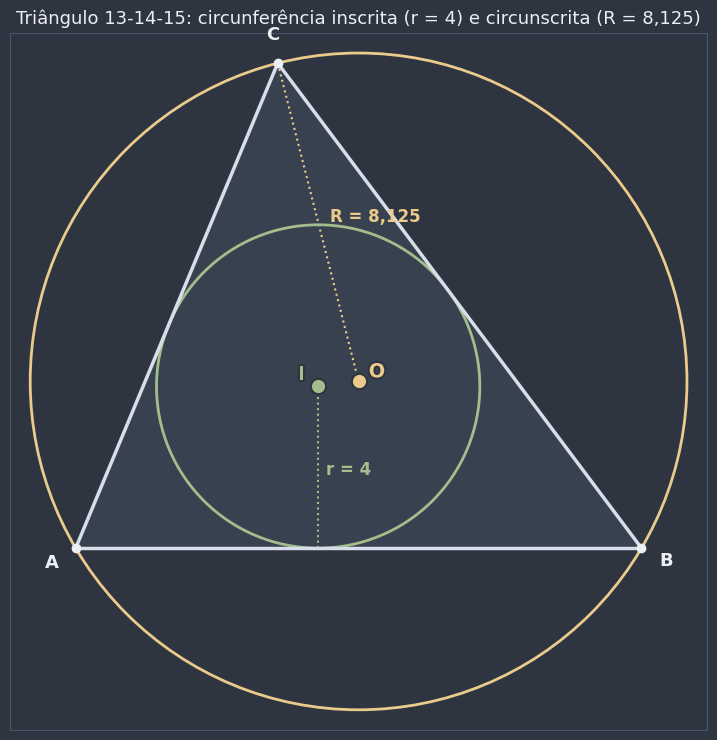

In [5]:
A_ex4, B_ex4, C_ex4 = como_pontos((0, 0), (14, 0), (5, 12))

# (a) Incentro pela fórmula: a = BC = 15, b = CA = 13, c = AB = 14.
#     I = (15·(0, 0) + 13·(14, 0) + 14·(5, 12)) / 42 = (182 + 70, 168) / 42 = (6, 4).
I_ex4 = incentro_pela_formula(A_ex4, B_ex4, C_ex4)
dist_lados_ex4 = list(distancias_aos_lados(I_ex4, A_ex4, B_ex4, C_ex4))
r_ex4 = dist_lados_ex4[0]  # as três são iguais

# (b) Circuncentro: a mediatriz de AB é a reta x = 7; o ponto (7, y) com OA = OC dá
#     49 + y² = 4 + (y − 12)²  ->  24y = 99  ->  y = 4,125.
O_ex4 = circuncentro(A_ex4, B_ex4, C_ex4)
dist_vertices_ex4 = [math.dist(O_ex4, V) for V in (A_ex4, B_ex4, C_ex4)]
R_ex4 = dist_vertices_ex4[0]  # √(49 + 4,125²) = √66,015625 = 8,125

# (c) A razão entre os raios.
R_sobre_r_ex4 = R_ex4 / r_ex4

print(f"lados: {[round(x, 6) for x in lados_do_triangulo(A_ex4, B_ex4, C_ex4)]}  (a, b, c)")
print(f"I = {I_ex4},  distâncias aos lados = {np.round(dist_lados_ex4, 6).tolist()},  r = {r_ex4:g}")
print(f"O = {O_ex4},  distâncias aos vértices = {np.round(dist_vertices_ex4, 6).tolist()},  R = {R_ex4:g}")
print(f"R / r = {R_sobre_r_ex4:g}  (maior que 2, por pouco)")

fig, ax = plt.subplots(figsize=(9, 7.5))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [O_ex4 + (R_ex4, R_ex4), O_ex4 - (R_ex4, R_ex4)], margem=0.5)
desenhar_circunferencia(ax, O_ex4, R_ex4, CORES_NOTAVEIS["O"], largura=2)
desenhar_circunferencia(ax, I_ex4, r_ex4, CORES_NOTAVEIS["I"], largura=2)
desenhar_triangulo(ax, A_ex4, B_ex4, C_ex4, distancia=0.7)
ax.plot(*zip(I_ex4, I_ex4 - (0, r_ex4)), color=CORES_NOTAVEIS["I"], lw=1.5, linestyle=":")
ax.text(I_ex4[0] + 0.2, I_ex4[1] - 2.2, "r = 4", color=CORES_NOTAVEIS["I"], fontsize=12, fontweight="bold")
ax.plot(*zip(O_ex4, C_ex4), color=CORES_NOTAVEIS["O"], lw=1.5, linestyle=":")
ax.text(*(ponto_medio(O_ex4, C_ex4) + (0.3, 0)), "R = 8,125", color=CORES_NOTAVEIS["O"], fontsize=12, fontweight="bold")
marcar_notavel(ax, I_ex4, "I")
marcar_notavel(ax, O_ex4, "O", deslocamento=(0.25, 0.1))
ax.set_title("Triângulo 13-14-15: circunferência inscrita (r = 4) e circunscrita (R = 8,125)", color=NORD_TEXTO,
             fontsize=13)
plt.tight_layout()
plt.show()
# Curiosidade: em TODO triângulo vale R ≥ 2r (a "desigualdade de Euler", do mesmo Euler da reta),
# e a igualdade R = 2r só acontece no equilátero. Aqui, R / r = 2,03: o 13-14-15 é "quase equilátero".

## Desafio

**Exercício 5.** A reta de Euler em 100 triângulos sorteados, a fração de incentros sobre ela e o incentro em 50 triângulos isósceles.

In [6]:
gerador_ex5 = np.random.default_rng(5)


def isosceles_aleatorio_ex5(gerador) -> list[np.ndarray]:
    """Triângulo isósceles (AB = AC) com base, altura, giro e posição sorteados."""
    meia_base, altura = gerador.uniform(1, 6, 2)
    giro = gerador.uniform(0, 360)
    deslocamento = gerador.uniform(-5, 5, 2)
    A, B, C = np.array([0.0, altura]), np.array([-meia_base, 0.0]), np.array([meia_base, 0.0])
    rotacao = np.column_stack([direcao(giro), direcao(giro + 90)])  # gira os pontos em torno da origem
    return [rotacao @ V + deslocamento for V in (A, B, C)]


def incentro_na_reta_de_euler(A, B, C) -> bool:
    """True se o incentro está sobre a reta HO (a menos de 1e-6)."""
    H, O, I = ortocentro(A, B, C), circuncentro(A, B, C), incentro(A, B, C)
    return distancia_ponto_reta(I, H, direcao_de(H, O)) < 1e-6


# (a) e (b): 100 triângulos "não achatados".
colineares, razoes, incentro_na_reta = [], [], []
while len(colineares) < 100:
    A, B, C = gerador_ex5.uniform(-10, 10, (3, 2))
    if min(angulos_do_triangulo(A, B, C)) < 5:
        continue  # com um ângulo muito pequeno, H e O vão para muito longe e os arredondamentos crescem
    H, G, O = ortocentro(A, B, C), baricentro(A, B, C), circuncentro(A, B, C)
    colineares.append(math.isclose(orientacao(H, G, O), 0, abs_tol=1e-6))
    razoes.append(math.isclose(math.dist(H, G), 2 * math.dist(G, O), rel_tol=1e-6))
    incentro_na_reta.append(incentro_na_reta_de_euler(A, B, C))
todos_colineares_ex5 = all(colineares)
todas_razoes_ex5 = all(razoes)
fracao_I_na_reta_ex5 = sum(incentro_na_reta) / len(incentro_na_reta)

# (c): 50 isósceles em posições quaisquer.
isosceles_I_na_reta_ex5 = all(incentro_na_reta_de_euler(*isosceles_aleatorio_ex5(gerador_ex5)) for _ in range(50))

print(f"H, G, O colineares nos 100? {todos_colineares_ex5}")
print(f"HG = 2·GO nos 100? {todas_razoes_ex5}")
print(f"fração com o incentro na reta de Euler: {fracao_I_na_reta_ex5}")
print(f"nos 50 isósceles, o incentro está na reta? {isosceles_I_na_reta_ex5}")

H, G, O colineares nos 100? True
HG = 2·GO nos 100? True
fração com o incentro na reta de Euler: 0.0
nos 50 isósceles, o incentro está na reta? True


**Por que a reta de Euler existe?** *(para quem quiser ir além)* Os testes dão confiança, mas uma demonstração curta cabe aqui, com coordenadas e o **produto escalar** que apareceu em [`0409a_paralelogramos_e_casos_particulares.ipynb`](0409a_paralelogramos_e_casos_particulares.ipynb) (dois vetores são perpendiculares quando o produto escalar é zero).

Coloque a origem no circuncentro $O$. Então $|A| = |B| = |C| = R$. Considere o ponto $P = A + B + C$:

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $(P - A) \cdot (C - B) = (B + C) \cdot (C - B) = \lvert C\rvert^2 - \lvert B\rvert^2$ | distributiva do produto escalar |
| 2 | $\lvert C\rvert^2 - \lvert B\rvert^2 = R^2 - R^2 = 0$ | $O$ é o circuncentro ($OB = OC = R$) |
| 3 | $\overline{AP} \perp \overline{BC}$: $P$ está na altura que sai de $A$ | passos 1 e 2 |
| 4 | $P$ também está nas alturas que saem de $B$ e de $C$ | o mesmo cálculo, trocando os papéis |
| 5 | $H = A + B + C$ | $P$ está nas três alturas: é o ortocentro |
| 6 | $G = \dfrac{A + B + C}{3} = \dfrac{H}{3}$ | seção 1 do notebook principal |

Com a origem em $O$, o passo 6 diz que $G$ está no segmento $\overline{OH}$, a $\frac{1}{3}$ do caminho de $O$ até $H$. Logo $O$, $G$ e $H$ são colineares, com $GO = \frac{1}{3}HO$ e $HG = \frac{2}{3}HO$, ou seja, $HG = 2 \cdot GO$. ∎ (Sem mudar a origem, o passo 5 fica $H = A + B + C - 2O$.)

In [7]:
gerador = np.random.default_rng(10)
for _ in range(5):
    A, B, C = gerador.uniform(-10, 10, (3, 2))
    H, O = ortocentro(A, B, C), circuncentro(A, B, C)
    print(f"H = ({H[0]:9.4f}, {H[1]:9.4f})   A + B + C − 2O = ({(A + B + C - 2 * O)[0]:9.4f}, "
          f"{(A + B + C - 2 * O)[1]:9.4f})   iguais? {np.allclose(H, A + B + C - 2 * O)}")

H = (  10.0901,  -28.7611)   A + B + C − 2O = (  10.0901,  -28.7611)   iguais? True
H = (  13.7136,   13.2538)   A + B + C − 2O = (  13.7136,   13.2538)   iguais? True
H = (   6.9611,  -14.7079)   A + B + C − 2O = (   6.9611,  -14.7079)   iguais? True
H = (  -5.4121,    6.8917)   A + B + C − 2O = (  -5.4121,    6.8917)   iguais? True
H = (  -6.2723,    1.1246)   A + B + C − 2O = (  -6.2723,    1.1246)   iguais? True


**Exercício 6.** O posto de saúde para os bairros $A = (0, 0)$, $B = (10, 0)$ e $C = (2, 2)$: o ponto equidistante (circuncentro) contra o ponto médio do maior lado.

ângulos: [45.0, 14.04, 120.96]  ->  obtusângulo
O = [ 5. -3.],  R = 5.8310 km,  O está fora do triângulo
M = [5. 0.],  distâncias de M: [5.0, 5.0, 3.6056]
melhor projeto: M


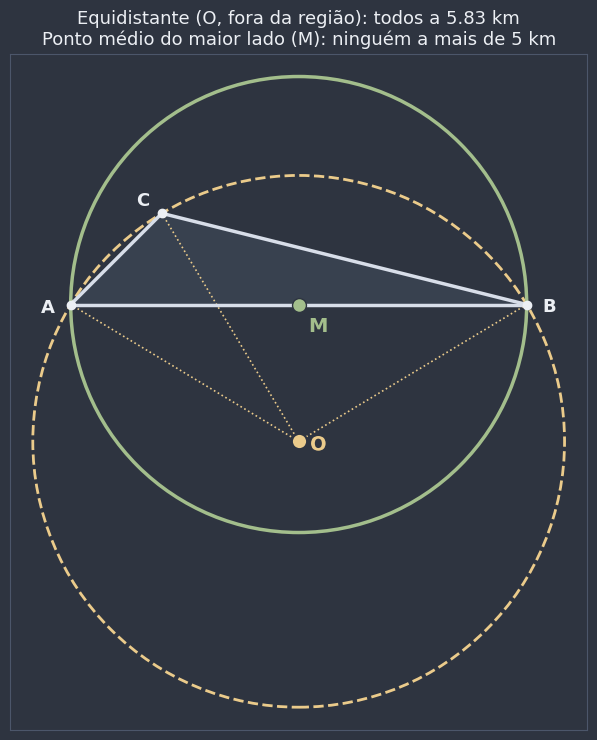

In [8]:
BAIRROS_EX6 = dict(zip(["Ameixeira", "Bela Vista", "Cachoeira"], como_pontos((0, 0), (10, 0), (2, 2))))
A_ex6, B_ex6, C_ex6 = BAIRROS_EX6.values()

# (a) O ângulo em C: os vetores CA = (−2, −2) e CB = (8, −2) formam mais de 90°.
classificacao_ex6 = classificar_por_angulos(A_ex6, B_ex6, C_ex6)

# (b) O ponto equidistante dos três vértices é o circuncentro. A mediatriz de AB é x = 5; o ponto
#     (5, y) com OA = OC dá 25 + y² = 9 + (y − 2)²  ->  4y = −12  ->  y = −3.
O_ex6 = circuncentro(A_ex6, B_ex6, C_ex6)
R_ex6 = math.dist(O_ex6, A_ex6)  # √(25 + 9) = √34 ≈ 5,83 km

# (c) Obtusângulo: o circuncentro fica fora, do outro lado do maior lado AB.
posicao_ex6 = posicao_no_triangulo(O_ex6, A_ex6, B_ex6, C_ex6)

# (d) O maior lado é AB = 10 (o oposto ao ângulo obtuso, 0404a).
M_ex6 = ponto_medio(A_ex6, B_ex6)
maior_distancia_M_ex6 = max(math.dist(M_ex6, V) for V in (A_ex6, B_ex6, C_ex6))  # MA = MB = 5, MC = √13

# (e) Em M, o morador mais distante anda 5 km; em O, todos andam √34 ≈ 5,83 km.
melhor_projeto_ex6 = "M" if maior_distancia_M_ex6 < R_ex6 else "O"

print(f"ângulos: {[round(x, 2) for x in angulos_do_triangulo(A_ex6, B_ex6, C_ex6)]}  ->  {classificacao_ex6}")
print(f"O = {O_ex6},  R = {R_ex6:.4f} km,  O está {posicao_ex6} do triângulo")
print(f"M = {M_ex6},  distâncias de M: {[round(math.dist(M_ex6, V), 4) for V in (A_ex6, B_ex6, C_ex6)]}")
print(f"melhor projeto: {melhor_projeto_ex6}")

fig, ax = plt.subplots(figsize=(10, 7.5))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [O_ex6 + (R_ex6, R_ex6), O_ex6 - (R_ex6, R_ex6), M_ex6 + (5, 5)], margem=0.5)
desenhar_circunferencia(ax, O_ex6, R_ex6, CORES_NOTAVEIS["O"], estilo="--", largura=2)
desenhar_circunferencia(ax, M_ex6, maior_distancia_M_ex6, COR_DESTAQUE, largura=2.5)
desenhar_triangulo(ax, A_ex6, B_ex6, C_ex6, distancia=0.5)
for V in (A_ex6, B_ex6, C_ex6):
    ax.plot(*zip(O_ex6, V), color=CORES_NOTAVEIS["O"], lw=1.2, linestyle=":")
marcar_notavel(ax, O_ex6, "O", deslocamento=(0.25, -0.2))
ax.plot(*M_ex6, "o", color=COR_DESTAQUE, markersize=10, markeredgecolor=NORD_FUNDO, zorder=8)
ax.text(M_ex6[0] + 0.2, M_ex6[1] - 0.6, "M", color=COR_DESTAQUE, fontsize=14, fontweight="bold")
ax.set_title(f"Equidistante (O, fora da região): todos a {R_ex6:.2f} km\n"
             f"Ponto médio do maior lado (M): ninguém a mais de {maior_distancia_M_ex6:g} km", color=NORD_TEXTO,
             fontsize=13)
plt.tight_layout()
plt.show()

**O que isso significa para o planejamento.** "Equidistante" não é a mesma coisa que "melhor". Num triângulo obtusângulo, o ponto equidistante dos três bairros (o circuncentro) cai **fora** da região delimitada por eles, do outro lado do maior lado: o posto ficaria longe de todo mundo, num lugar que talvez nem pertença à cidade (pode ser um rio, uma área de preservação, outro município).

Se o critério é "o morador mais distante deve andar o mínimo possível", a resposta é o centro do **menor círculo que contém os três bairros**. Num triângulo **obtusângulo** (ou retângulo), esse círculo tem o **maior lado como diâmetro**, e o centro é o ponto médio $M$ desse lado: o terceiro bairro fica do lado de dentro porque o ângulo dele é obtuso (você vai entender o porquê em [`0413a_angulos_na_circunferencia.ipynb`](0413a_angulos_na_circunferencia.ipynb)). Só num triângulo **acutângulo** o menor círculo é a própria circunferência circunscrita, e aí o circuncentro é mesmo a melhor escolha.

Esse "problema do menor círculo" (em inglês, *smallest enclosing circle*) aparece de verdade na instalação de antenas, de sirenes de alerta e de serviços de emergência, sempre que o pior caso é o que importa.